# U'n'Eye: Convolutional Neural Network for eye movement detection

Call the model with uneye.DNN(sampfreq) and then run training / testing / prediction with the method model.train(), model.test() or model.predict(), respectively.

Optional input arguments when calling uneye.DNN() are:
- min_sacc_dur: minimum saccade duration (in ms) for removal of small saccades (post-processing), default: 1==no removal
- min_sacc_dist: minimum distance (in ms) between two saccades for merging of close-by saccades, default: 1==no merge
- weights_name: filename for storage of trained weights. All trained weights will automatically be safed in the local folder 'training'. The default filename is 'weights'
- augmentation: True or False. Whether data augmentation (rotation of signal) should be used. The default is 'True'.
- ks: kernel size of convolutional layers. Has to be odd. Default: 5
- mp: size of max pooling window. Has to be odd. Default: 5
- inf_correction: Float value to replace infs or NaNs in differentiated input data (i.e. eye velocity). Should correspond to maximum value that is expected. Default: 1.5
- val_samples: Number of trials used for validating when to stop training early. Default: 30

# Training

Before running the model, do the following steps:
1) run the function 'PrepareEyeData4iLabel.ipynb' in order to prepare eye data for labeling
2) run iLabel GUI on matlab in order to label a training and a testing dataset
3) run matlab function that combines all labels in a common matrix that can be used with UnEye

                |
                V

Train network with own training data (example data in folder 'data').

For training, 3 inputs are **necessary**:
    - horizontal eye position (in deg)
    - vertical eye position (in deg)
    - ground truth labels for saccades (encoded as 1). Fixation encoded as 0. Additional labels are optional (e.g. post-saccadic oscillation, encoded as 2 etc.)
    
    
**model.train(X,Y,Labels)**   

In [1]:

import numpy as np
import uneye
import scipy.io as io
from os.path import join as pj
import matplotlib.pyplot as plt


In [2]:
########### Eye DATA ############

# data for training
datapathTrain = '/mnt/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection/data4UnEye_merged/'
x_train_filename = 'X_train.csv'
y_train_filename = 'Y_train.csv'
labels_train_filename = 'L_train.csv'

# data for testing 1
datapathTest = '/mnt/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection/data4UnEye_merged'
x_test_filename = 'X_test.csv' 
y_test_filename = 'Y_test.csv'
labels_test_filename = 'L_test.csv'

##################################
########### Parameters ###########
min_sacc_dur = 8 #minimum saccade duration in ms
min_sacc_dist = 15 #minimum saccade distance in ms
sampfreq = 500 # irec sampling frequency in Hz

weights_name = 'weights_15dist'


In [3]:
import numpy as np
import uneye
import scipy.io as io
from os.path import join as pj

# load training data (.csv)
Xtrain = np.loadtxt(pj(datapathTrain,x_train_filename),delimiter=',')
Ytrain = np.loadtxt(pj(datapathTrain,y_train_filename),delimiter=',')
Ltrain = np.loadtxt(pj(datapathTrain,labels_train_filename),delimiter=',')

# example dataset is large, so use only subset for training:
ntrain = Xtrain.shape[0] # all or less samples/trials for training
Xtrain = Xtrain[:ntrain,:]
Ytrain = Ytrain[:ntrain,:]
Ltrain = Ltrain[:ntrain,:]

# load .mat example data
#Xtrain,Ytrain,Ltrain = io.loadmat(datapath+'X_train.mat')['X'],io.loadmat(datapath+'Y_train.mat')['Y'],io.loadmat(datapath+'Sacc_train.mat')['Sacc']

# fit model on training data
# weights will automatically be saved to local folder 'training'
# call model with optional arguments
model = uneye.DNN(sampfreq=sampfreq,
                  weights_name=weights_name,
                  min_sacc_dur=min_sacc_dur,
                  min_sacc_dist=min_sacc_dist)
model.train(Xtrain,Ytrain,Ltrain)

Number of classes: 2
Using GPU: False
Training. Please wait.
Early stopping at epoch 60 before overfitting occurred.
Model parameters saved to ./training/weights_15dist


In [4]:
# Use this to load model weights 
# call model with optional arguments
weights_name = "weights_synthetic"

model = uneye.DNN(sampfreq=sampfreq,
                  weights_name=weights_name,
                  min_sacc_dur=min_sacc_dur,
                  min_sacc_dist=min_sacc_dist)


In [5]:
print(Xtrain.shape)
print(datapathTrain)
print(model)
print(dir(model))


(160, 1500)
/mnt/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection/data4UnEye_merged/
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'augmentation', 'crossvalidate', 'doDiff', 'inf_correction', 'ks', 'lr', 'max_iter', 'min_sacc_dist', 'min_sacc_dur', 'mp', 'predict', 'sampfreq', 'test', 'train', 'use_gpu', 'val_samples', 'weights_name']


In [6]:
# plot loss
import matplotlib.pyplot as plt
f = plt.figure(figsize=(4,3))
plt.plot(model.loss_train,label='training')
plt.plot(model.loss_val,label='test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and test loss')
plt.legend()
plt.tight_layout()
plt.show()

AttributeError: 'DNN' object has no attribute 'loss_train'

<Figure size 400x300 with 0 Axes>

### Test after training network
Test performance with separate test data (here, synthetic example data is used).


For testing, 3 inputs are **necessary**:
    - horizontal eye position (in deg)
    - vertical eye position (in deg)
    - ground truth labels for saccades (encoded as 1). Additional labels are optional (e.g. post-saccadic oscillation, encoded as 2 etc.)    
  
**model.test()**

If you just trained the network before, you can directly apply **model.test()** to the trained model. Otherwise you have to specify the correct weights_name.

In [3]:
# load testing data (.csv)
Xtest= np.loadtxt(pj(datapathTest,x_test_filename),delimiter=',')
Ytest = np.loadtxt(pj(datapathTest,y_test_filename),delimiter=',')
Ltest = np.loadtxt(pj(datapathTest,labels_test_filename),delimiter=',')

# example dataset is large, so use only subset for testing:
ntest = Xtest.shape[0] # all or less samples/trials for testing
Xtest = Xtest[:ntest,:]
Ytest = Ytest[:ntest,:]
Ltest = Ltest[:ntest,:]

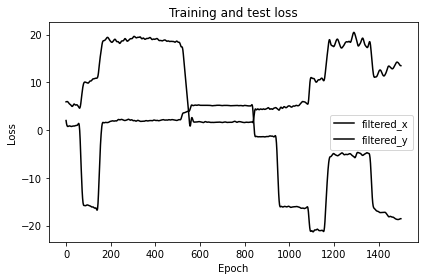

In [ ]:
f = plt.figure()
#plt.plot(XX[55],label='raw_x')
plt.plot(Xtest[55],label='x',color='black')

#plt.plot(YY[55],label='raw_x')
plt.plot(Ytest[55],label='y',color='black')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.tight_layout()
plt.show()

In [3]:
import os
print("cwd:", os.getcwd())
print("exists:", os.path.exists("./training/weights_synthetic"))

cwd: /mnt/hpc/projects/MWzeronoise/Analysis/4Elena/uneye
exists: True


In [4]:
# Test the model using filtered signals

Prediction, Probability, Performance = model.test(
    Xtest, Ytest, Ltest)


Binary Cohens Kappa:  0.863
F1: 0.931


In [26]:
print("Unique Ytest:", set(Ytest.flatten()) if hasattr(Ytest, "flatten") else None)


Unique Ytest: {0.77346, 1.0274, 2.5625, 2.6173, 4.1875, 5.125, 6.6678, 6.0625, 8.5548, 9.2423, 9.3168, 9.3519, 9.5428, 9.7654, 9.738, 10.137, 10.387, 10.637, 12.25, 16.625, 16.75, 18.399, 18.0, 19.149, 21.101, 21.0, 22.875, 23.0, 26.976, 20.625, 21.375, 22.125, 24.625, 25.125, 34.464, 26.5, 27.375, 29.125, 38.065, 30.375, 6.8125, 7.3125, 7.1875, 35.375, 7.5625, 36.25, 9.0, 38.0, 39.5, 8.125, 50.334, 10.875, 10.375, 10.25, 48.56, 48.464, 11.375, 11.625, 51.149, 2.1875, 11.125, 12.5, 12.625, 12.375, 12.125, 12.0, 13.0, 13.875, 22.188, 13.5, 1.5873, 14.125, 14.0, 14.25, 14.625, 14.875, 15.625, 15.375, 15.0, 14.375, 3.0873, 3.875, 16.125, 16.0, 16.375, 4.5248, 17.625, 17.875, -8.8879, 17.0, 5.0873, 18.625, 18.375, 18.875, 18.5, 6.9623, 19.0, 19.25, 19.125, 19.75, 18.25, 20.0, 20.375, 20.875, 20.25, -5.3254, 21.625, 21.125, 4.125, 4.5, 21.875, 22.625, 22.75, -4.7629, 22.375, 21.5, 23.875, 3.3497, -2.7004, -2.8254, 23.25, 24.375, 24.25, 24.5, 24.75, 23.375, 25.25, 25.625, 25.875, -34.626, 0.

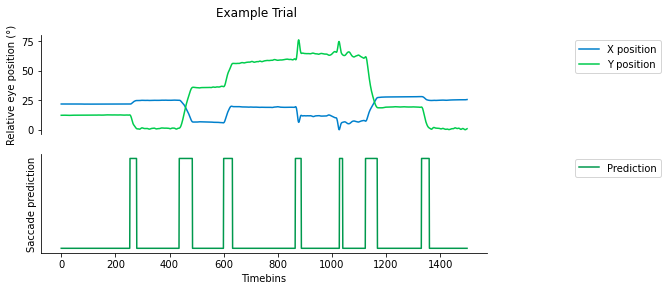

In [33]:
# plot example
i = np.random.randint(Xtest.shape[0])
fig = plt.figure(figsize=(8,4))
plt.suptitle('Example Trial')
ax = fig.add_subplot(211)
x_trace = Xtest[i,:] - np.min(Xtest[i,:])
y_trace = Ytest[i,:] - np.min(Ytest[i,:])
plt.plot(x_trace,label='X position',c=[0,0.5,0.8])
plt.plot(y_trace,label='Y position',c=[0,0.8,0.3])
plt.xticks(())
plt.ylabel('Relative eye position (°)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.legend(bbox_to_anchor=(1.4,1))

# prediction
ax = fig.add_subplot(212)
#plt.plot(Ltest[i,:]+2.4,label='Ground truth',c='k')
plt.plot(Prediction[i,:]+1.2,label='Prediction',c=[0,0.6,0.3])
#plt.plot(Probability2[i,:],label='Saccade probability',c='k',alpha=.3)
plt.yticks(())
plt.ylabel('Saccade prediction')
plt.xlabel('Timebins')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(bbox_to_anchor=(1.4,1))
plt.show()

In [16]:
########### YOUR DATA ############
#datapath = 'data/Synthetic/' #example data

#x_filename = 'X_test.csv'
#y_filename = 'Y_test.csv'
#labels_filename = 'L_test.csv'
##################################

# load example test data
Xtest = np.loadtxt(pj(datapath,x_filename),delimiter=',')
Ytest = np.loadtxt(pj(datapath,y_filename),delimiter=',')
Ltest = np.loadtxt(pj(datapath,labels_filename),delimiter=',')

# reduce data to subset that wasn't used for training (only needed for this example)
Xtest = Xtest[ntrain:,:]
Ytest = Ytest[ntrain:,:]
Ltest = Ltest[ntrain:,:]

# test performance (here on subset of data that wasn't used for training)
Prediction,Probability,Performance = model.test(Xtest,Ytest,Ltest)

NameError: name 'datapath' is not defined

# Saccade prediction with pretrained network
Predict eye-movements in data (synthetic example data in folder 'data').


For prediction, 3 inputs are **necessary**:
    - horizontal eye position (in deg)
    - vertical eye position (in deg)
    - sampling frequency of the eye tracker
    
  
Call the model with at least two arguments **ueye.DNN(sampfreq,weights_name)** and then run prediction with the method **model.predict()**

In [ ]:
# Predict saccade onsets
datapathInfer = '/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection/data4UnEye_merged/4Inference'

x_filename = 'infer_y.csv'
y_filename = 'infer_x.csv'

Xinfer = np.loadtxt(pj(datapathInfer,x_filename),delimiter=',')
Yinfer = np.loadtxt(pj(datapathInfer,y_filename),delimiter=',')

Prediction2,Probability2 = model.predict(Xinfer,Yinfer)

In [ ]:
# code to save saccades predictions of the whole dataset
# Note that one can later on remove microsaccades using an easy threshold


import os

out_dir = os.path.join(datapathInfer, "model_outputs")
os.makedirs(out_dir, exist_ok=True)

np.savez(
    os.path.join(out_dir, "uneye_inference_outputs.npz"),
    Prediction2=Prediction2,        # shape: (n_trials, 1, time)
    Probability2=Probability2,      # shape: (n_trials, 2, time)
    fs=fs,
    description="U'n'Eye inference outputs (Prediction2 + Probability2)"
)

os.chdir(out_dir)

## Code to load the file later on 

#d = np.load("uneye_inference_outputs.npz", allow_pickle=True)
#Prediction2 = d["Prediction2"]
#Probability2 = d["Probability2"]
#fs = int(d["fs"])

# Prediction2.shape



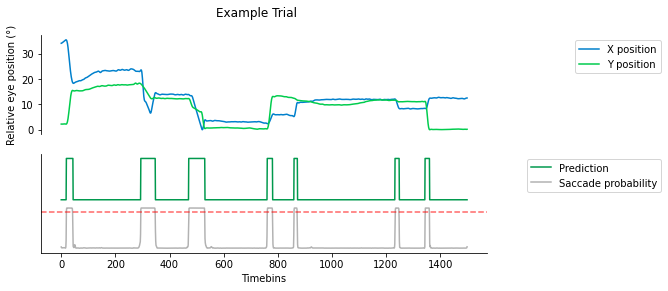

In [115]:
# plot x, y and probability 

# plot example
i = np.random.randint(Xtest.shape[0])
fig = plt.figure(figsize=(8,4))
plt.suptitle('Example Trial')
ax = fig.add_subplot(211)
x_trace = Xinfer[i,:] - np.min(Xinfer[i,:])
y_trace = Yinfer[i,:] - np.min(Yinfer[i,:])
plt.plot(x_trace,label='X position',c=[0,0.5,0.8])
plt.plot(y_trace,label='Y position',c=[0,0.8,0.3])
plt.xticks(())
plt.ylabel('Relative eye position (°)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.legend(bbox_to_anchor=(1.4,1))

# prediction
ax = fig.add_subplot(212)
plt.plot(Prediction2[i,:]+1.2,label='Prediction',c=[0,0.6,0.3])
plt.plot(Probability2[i,1,:],label='Saccade probability',c='k',alpha=.3)
plt.yticks(())
#plt.ylabel('Saccade prediction')
plt.xlabel('Timebins')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(bbox_to_anchor=(1.4,1))
plt.axhline(0.9, linestyle='--', color='r', alpha=0.6, label='0.8 threshold')

plt.show()

In [ ]:
# plot example
i = np.random.randint(Xtest.shape[0])
fig = plt.figure(figsize=(8,4))
plt.suptitle('Example Trial')
ax = fig.add_subplot(211)
x_trace = Xinfer[i,:] - np.min(Xinfer[i,:])
y_trace = Yinfer[i,:] - np.min(Yinfer[i,:])
plt.plot(x_trace,label='X position',c=[0,0.5,0.8])
plt.plot(y_trace,label='Y position',c=[0,0.8,0.3])
plt.xticks(())
plt.ylabel('Relative eye position (°)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.legend(bbox_to_anchor=(1.4,1))

# prediction
ax = fig.add_subplot(212)
plt.plot(Prediction2[i,:]+1.2,label='Prediction',c=[0,0.6,0.3])
plt.plot(Probability2[i,:],label='Saccade probability',c='k',alpha=.3)
plt.yticks(())
#plt.ylabel('Saccade prediction')
plt.xlabel('Timebins')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(bbox_to_anchor=(1.4,1))
plt.show()

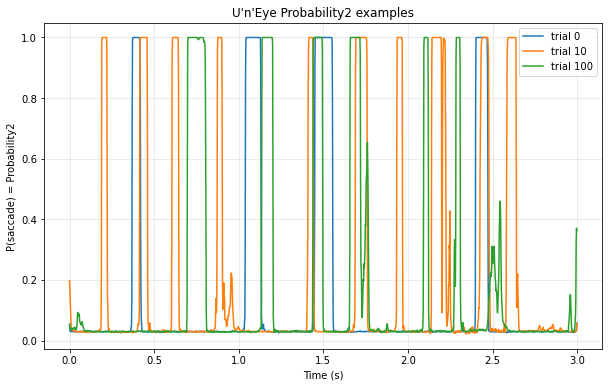

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# prob has shape (n_trials, 2, time)
# Example: prob = Probability2_array

fs = 500  # Hz
time = np.arange(Probability2.shape[2]) / fs

example_trials = [0, 10, 100]  # pick any indices you want

plt.figure(figsize=(10, 6))

for i in example_trials:
    plt.plot(time, Probability2[i, 1, :], label=f"trial {i}")

plt.xlabel("Time (s)")
plt.ylabel("P(saccade) = Probability2")
plt.title("U'n'Eye Probability2 examples")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
